# EDA 005 — Core Stages of a Data Pipeline

**Building Systems Around the Model**

A machine-learning model is only as good as the data fed into it. This notebook walks through the four sequential stages every production pipeline follows:

| Stage | Goal |
|---|---|
| **1 — Ingest** | Collect data from files, databases, APIs or streams in a structured, traceable way |
| **2 — Clean** | Fix missing values, inconsistencies and duplicates; stabilise the pipeline foundation |
| **3 — Transform** | Reshape the data with aggregations, joins and structural changes |
| **4 — Feature Engineering** | Engineer predictive variables from raw signals |

Each stage builds on the last. We use a synthetic e-commerce dataset (orders, customers, products) generated in-notebook so nothing external is required.


## Setup

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)


## Pipeline Overview

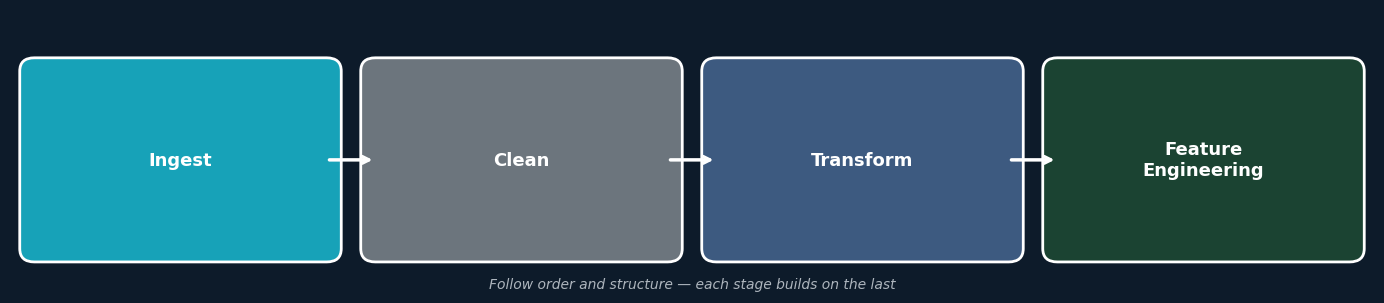

In [42]:
fig, ax = plt.subplots(figsize=(14, 3.2))
ax.set_xlim(0, 14); ax.set_ylim(0, 3.2); ax.axis('off')
fig.patch.set_facecolor('#0d1b2a')
ax.set_facecolor('#0d1b2a')

stages = [
    ('Ingest',               '#17a2b8'),
    ('Clean',                '#6c757d'),
    ('Transform',            '#3d5a80'),
    ('Feature\nEngineering', '#1b4332'),
]

box_w  = 3.0
gap    = 0.5
total  = len(stages) * box_w + (len(stages) - 1) * gap   # 13.5
start  = (14 - total) / 2                                 # 0.25 — centred

for i, (label, color) in enumerate(stages):
    x = start + i * (box_w + gap)
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, 0.5), box_w, 2.0,
        boxstyle='round,pad=0.15',
        facecolor=color, edgecolor='white', linewidth=2, zorder=2,
    ))
    ax.text(x + box_w / 2, 1.5, label,
            ha='center', va='center', color='white',
            fontsize=13, fontweight='bold', zorder=3)
    if i < len(stages) - 1:
        ax.annotate(
            '', xy=(x + box_w + gap, 1.5), xytext=(x + box_w, 1.5),
            arrowprops=dict(arrowstyle='->', color='white', lw=2.5),
            zorder=4,
        )

ax.text(7, 0.1,
        'Follow order and structure — each stage builds on the last',
        ha='center', va='center', color='#adb5bd', fontsize=10, style='italic')

plt.tight_layout()
plt.show()


---
## Stage 1 — Ingest

> *Collect data from files, databases, APIs or streams. Load data in a structured, traceable way.*

Real pipelines pull from multiple sources simultaneously:
- **Files** — CSV, Parquet, JSON exports
- **Databases** — SQL queries via SQLAlchemy / sqlite3
- **APIs / streams** — REST endpoints, Kafka topics

We generate three realistic raw tables here, intentionally injecting noise (missing values, typos, duplicates) that Stage 2 will fix.


### 1.1 — Generate raw source tables

In [43]:
rng = np.random.default_rng(42)

N_ORDERS    = 500
N_CUSTOMERS = 120
N_PRODUCTS  = 30

# ── Customers table ───────────────────────────────────────────────────────────
cities = ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix',
          'Philadelphia', 'San Antonio', 'San Diego', 'Dallas', 'San Jose']
genders = ['M', 'F', 'F', 'M', 'Other']

customers_raw = pd.DataFrame({
    'customer_id': [f'C{i:04d}' for i in range(N_CUSTOMERS)],
    'name':        [f'Customer_{i}' for i in range(N_CUSTOMERS)],
    'age':         rng.integers(18, 75, N_CUSTOMERS).astype(float),
    'city':        rng.choice(cities, N_CUSTOMERS),
    'gender':      rng.choice(genders, N_CUSTOMERS),
    'signup_date': pd.date_range('2019-01-01', periods=N_CUSTOMERS, freq='3D').strftime('%Y-%m-%d'),
})
# Inject noise
customers_raw.loc[rng.choice(N_CUSTOMERS, 12, replace=False), 'age'] = np.nan
customers_raw.loc[rng.choice(N_CUSTOMERS, 8,  replace=False), 'city'] =     rng.choice(['new york', 'LOS ANGELES', 'chicago ', ' Houston'], 8)
customers_raw = pd.concat([customers_raw, customers_raw.iloc[:5]], ignore_index=True)  # duplicates

print(f"customers_raw  shape: {customers_raw.shape}")
customers_raw.head(6)


customers_raw  shape: (125, 6)


,customer_id,name,age,city,gender,signup_date
0,C0000,Customer_0,23.00,Phoenix,M,2019-01-01
1,C0001,Customer_1,62.00,San Antonio,F,2019-01-04
2,C0002,Customer_2,NaN,San Antonio,M,2019-01-07
3,C0003,Customer_3,43.00,Phoenix,M,2019-01-10
4,C0004,Customer_4,42.00,Dallas,M,2019-01-13
5,C0005,Customer_5,66.00,new york,M,2019-01-16


In [44]:
# ── Products table ────────────────────────────────────────────────────────────
categories = ['Electronics', 'Clothing', 'Home & Garden', 'Sports', 'Books', 'Toys']

products_raw = pd.DataFrame({
    'product_id': [f'P{i:03d}' for i in range(N_PRODUCTS)],
    'name':       [f'Product_{i}' for i in range(N_PRODUCTS)],
    'category':   rng.choice(categories, N_PRODUCTS),
    'unit_price':  rng.uniform(5, 500, N_PRODUCTS).round(2),
})
# Inject noise
products_raw.loc[rng.choice(N_PRODUCTS, 3, replace=False), 'unit_price'] = np.nan

print(f"products_raw   shape: {products_raw.shape}")
products_raw.head(6)


products_raw   shape: (30, 4)


,product_id,name,category,unit_price
0,P000,Product_0,Home & Garden,464.14
1,P001,Product_1,Electronics,201.80
2,P002,Product_2,Toys,153.97
3,P003,Product_3,Electronics,NaN
4,P004,Product_4,Clothing,333.12
5,P005,Product_5,Clothing,478.03


In [45]:
# ── Orders table ──────────────────────────────────────────────────────────────
statuses = ['completed', 'cancelled', 'pending', 'refunded']

orders_raw = pd.DataFrame({
    'order_id':    [f'O{i:05d}' for i in range(N_ORDERS)],
    'customer_id': rng.choice(customers_raw['customer_id'].unique(), N_ORDERS),
    'product_id':  rng.choice(products_raw['product_id'],            N_ORDERS),
    'quantity':    rng.integers(1, 6, N_ORDERS),
    'discount':    rng.choice([0.0, 0.05, 0.10, 0.15, 0.20], N_ORDERS),
    'status':      rng.choice(statuses, N_ORDERS, p=[0.7, 0.1, 0.1, 0.1]),
    'order_date':  [
        (datetime(2022, 1, 1) + timedelta(days=int(d))).strftime('%d/%m/%Y')
        for d in rng.integers(0, 730, N_ORDERS)
    ],
})
# Inject noise
orders_raw.loc[rng.choice(N_ORDERS, 20, replace=False), 'quantity'] = np.nan
orders_raw.loc[rng.choice(N_ORDERS, 15, replace=False), 'status'] =     rng.choice(['Completed', 'CANCELLED', 'Pending'], 15)
orders_raw = pd.concat([orders_raw, orders_raw.iloc[:10]], ignore_index=True)  # duplicates

print(f"orders_raw     shape: {orders_raw.shape}")
orders_raw.head(6)


orders_raw     shape: (510, 7)


,order_id,customer_id,product_id,quantity,discount,status,order_date
0,O00000,C0078,P022,2.00,0.00,completed,14/03/2022
1,O00001,C0115,P016,2.00,0.05,completed,15/08/2022
2,O00002,C0104,P026,2.00,0.10,completed,28/05/2022
3,O00003,C0032,P003,3.00,0.15,completed,13/01/2022
4,O00004,C0054,P027,2.00,0.00,pending,11/10/2023
5,O00005,C0063,P025,5.00,0.10,cancelled,04/09/2023


### 1.2 — Ingest diagnostics

In [46]:
def ingest_report(name, df):
    """Print a quick shape / dtypes / missing summary on load."""
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"  rows={df.shape[0]:,}  cols={df.shape[1]}")
    print(f"  dtypes: {dict(df.dtypes.value_counts())}")
    missing = df.isnull().sum()
    if missing.any():
        print(f"  missing:\n{missing[missing > 0].to_string()}")
    dups = df.duplicated().sum()
    print(f"  duplicates: {dups}")
    print()

ingest_report('customers_raw', customers_raw)
ingest_report('products_raw',  products_raw)
ingest_report('orders_raw',    orders_raw)


  customers_raw
  rows=125  cols=6
  dtypes: {dtype('O'): np.int64(5), dtype('float64'): np.int64(1)}
  missing:
age    13
  duplicates: 5

  products_raw
  rows=30  cols=4
  dtypes: {dtype('O'): np.int64(3), dtype('float64'): np.int64(1)}
  missing:
unit_price    3
  duplicates: 0

  orders_raw
  rows=510  cols=7
  dtypes: {dtype('O'): np.int64(5), dtype('float64'): np.int64(2)}
  missing:
quantity    20
  duplicates: 10



---
## Stage 2 — Clean

> *Clean data to fix missing values, inconsistencies and duplicates. Stabilise the pipeline foundation.*

Clean operates on each source table independently before any join. Problems to fix:

| Problem | Where | Fix |
|---|---|---|
| Missing `age` | customers | median imputation |
| Missing `unit_price` | products | median imputation |
| Missing `quantity` | orders | mode imputation |
| City name casing / whitespace | customers | `.str.strip().str.title()` |
| Status casing | orders | `.str.strip().str.lower()` |
| Exact duplicate rows | all | `.drop_duplicates()` |
| Date format (`dd/mm/YYYY`) | orders | `pd.to_datetime` with format |


### 2.1 — Clean customers

In [47]:
customers = customers_raw.copy()

# Drop exact duplicates
customers = customers.drop_duplicates()

# Fix city casing / whitespace
customers['city'] = customers['city'].str.strip().str.title()

# Impute missing age with median
age_median = customers['age'].median()
customers['age'] = customers['age'].fillna(age_median)
customers['age'] = customers['age'].astype(int)

# Parse signup_date
customers['signup_date'] = pd.to_datetime(customers['signup_date'])

print(f"customers: {customers_raw.shape} → {customers.shape}")
customers.head(4)


customers: (125, 6) → (120, 6)


,customer_id,name,age,city,gender,signup_date
0,C0000,Customer_0,23,Phoenix,M,2019-01-01
1,C0001,Customer_1,62,San Antonio,F,2019-01-04
2,C0002,Customer_2,44,San Antonio,M,2019-01-07
3,C0003,Customer_3,43,Phoenix,M,2019-01-10


### 2.2 — Clean products

In [48]:
products = products_raw.copy()

# Impute missing unit_price with category median
products['unit_price'] = products.groupby('category')['unit_price']                                   .transform(lambda s: s.fillna(s.median()))

print(f"products: {products_raw.shape} → {products.shape}")
print(f"Missing unit_price after clean: {products['unit_price'].isnull().sum()}")
products.head(4)


products: (30, 4) → (30, 4)
Missing unit_price after clean: 0


,product_id,name,category,unit_price
0,P000,Product_0,Home & Garden,464.14
1,P001,Product_1,Electronics,201.80
2,P002,Product_2,Toys,153.97
3,P003,Product_3,Electronics,201.80


### 2.3 — Clean orders

In [49]:
orders = orders_raw.copy()

# Drop exact duplicates
orders = orders.drop_duplicates()

# Normalise status (strip + lower)
orders['status'] = orders['status'].str.strip().str.lower()

# Impute missing quantity with mode (most common value)
qty_mode = orders['quantity'].mode()[0]
orders['quantity'] = orders['quantity'].fillna(qty_mode).astype(int)

# Parse order_date (stored as dd/mm/YYYY)
orders['order_date'] = pd.to_datetime(orders['order_date'], dayfirst=True)

print(f"orders: {orders_raw.shape} → {orders.shape}")
orders.head(4)


orders: (510, 7) → (500, 7)


,order_id,customer_id,product_id,quantity,discount,status,order_date
0,O00000,C0078,P022,2,0.00,completed,2022-03-14
1,O00001,C0115,P016,2,0.05,completed,2022-08-15
2,O00002,C0104,P026,2,0.10,completed,2022-05-28
3,O00003,C0032,P003,3,0.15,completed,2022-01-13


### 2.4 — Missingness visualisation (before vs after)

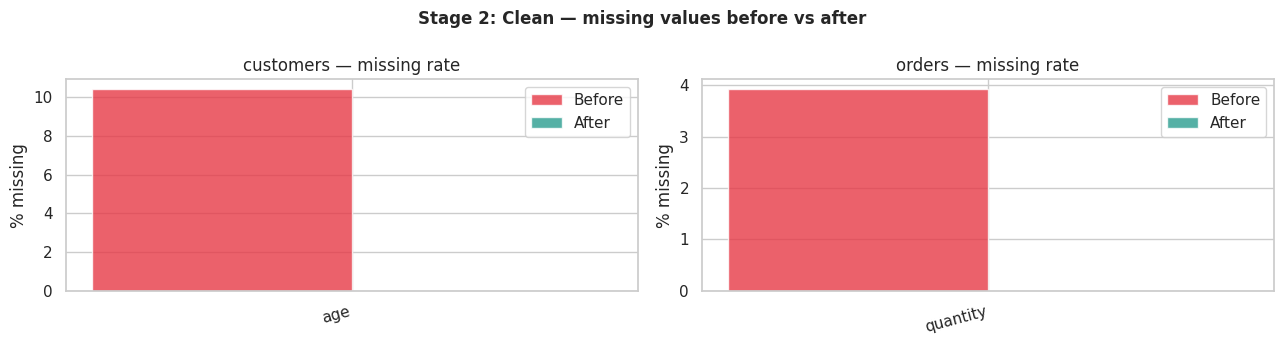

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

for ax, (label, raw, clean) in zip(axes, [
    ('customers', customers_raw, customers),
    ('orders',    orders_raw,    orders),
]):
    miss_before = raw.isnull().mean() * 100
    miss_after  = clean.isnull().mean() * 100
    cols = miss_before[miss_before > 0].index.tolist() or miss_before.index.tolist()[:5]

    x = np.arange(len(cols))
    w = 0.35
    ax.bar(x - w/2, miss_before[cols], w, label='Before', color='#e63946', alpha=0.8)
    ax.bar(x + w/2, miss_after[cols],  w, label='After',  color='#2a9d8f', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(cols, rotation=15, ha='right')
    ax.set_ylabel('% missing'); ax.set_title(f'{label} — missing rate')
    ax.legend()

plt.suptitle('Stage 2: Clean — missing values before vs after', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Stage 3 — Transform

> *Transform data with aggregations, joins and reshaping.*

Now the clean tables are combined and reshaped into an analysis-ready dataset:

1. **Join** — merge orders → products → customers
2. **Derive columns** — `revenue`, `order_year`, `order_month`, `order_dow`
3. **Aggregate** — customer-level summary features
4. **Filter** — keep only completed orders for the revenue model


### 3.1 — Join the three tables

In [51]:
# orders ← products ← customers
df = (
    orders
    .merge(products[['product_id', 'category', 'unit_price']], on='product_id', how='left')
    .merge(customers[['customer_id', 'age', 'city', 'gender', 'signup_date']], on='customer_id', how='left')
)

print(f"Joined shape: {df.shape}")
df.head(4)


Joined shape: (500, 13)


,order_id,customer_id,product_id,quantity,discount,status,order_date,category,unit_price,age,city,gender,signup_date
0,O00000,C0078,P022,2,0.00,completed,2022-03-14,Electronics,415.57,50,Houston,Other,2019-08-23
1,O00001,C0115,P016,2,0.05,completed,2022-08-15,Books,466.85,50,San Diego,Other,2019-12-12
2,O00002,C0104,P026,2,0.10,completed,2022-05-28,Books,304.98,63,San Diego,Other,2019-11-09
3,O00003,C0032,P003,3,0.15,completed,2022-01-13,Electronics,201.80,23,San Jose,M,2019-04-07


### 3.2 — Derive new columns

In [52]:
df['revenue']     = df['quantity'] * df['unit_price'] * (1 - df['discount'])
df['order_year']  = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_dow']   = df['order_date'].dt.day_of_week          # 0=Mon … 6=Sun
df['order_dow_name'] = df['order_date'].dt.day_name()
df['days_since_signup'] = (df['order_date'] - df['signup_date']).dt.days

print(f"Columns after derivation: {list(df.columns)}")
df[['order_id', 'revenue', 'order_year', 'order_month', 'order_dow', 'days_since_signup']].head(4)


Columns after derivation: ['order_id', 'customer_id', 'product_id', 'quantity', 'discount', 'status', 'order_date', 'category', 'unit_price', 'age', 'city', 'gender', 'signup_date', 'revenue', 'order_year', 'order_month', 'order_dow', 'order_dow_name', 'days_since_signup']


,order_id,revenue,order_year,order_month,order_dow,days_since_signup
0,O00000,831.14,2022,3,0,934
1,O00001,887.01,2022,8,0,977
2,O00002,548.96,2022,5,5,931
3,O00003,514.59,2022,1,3,1012


### 3.3 — Filter to completed orders only

In [53]:
df_completed = df[df['status'] == 'completed'].copy()
print(f"All orders: {len(df):,}  →  Completed: {len(df_completed):,}")
df_completed['status'].value_counts()


All orders: 500  →  Completed: 332


status
completed    332
Name: count, dtype: int64

### 3.4 — Aggregate: revenue by category and month

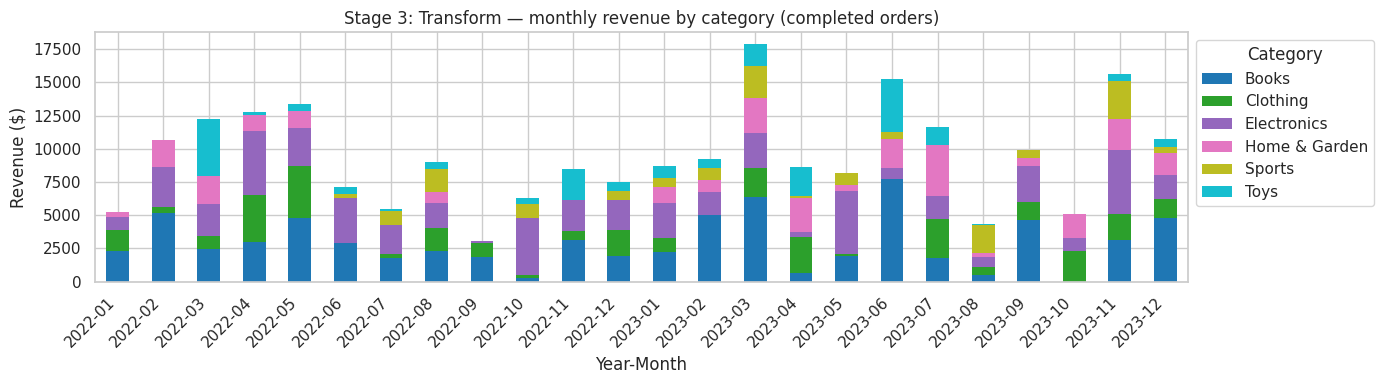

In [54]:
monthly_rev = (
    df_completed
    .groupby(['order_year', 'order_month', 'category'])['revenue']
    .sum()
    .reset_index()
    .sort_values(['order_year', 'order_month'])
)
monthly_rev['year_month'] = monthly_rev['order_year'].astype(str) + '-' +                              monthly_rev['order_month'].astype(str).str.zfill(2)

pivot = monthly_rev.pivot_table(index='year_month', columns='category', values='revenue', aggfunc='sum').fillna(0)

fig, ax = plt.subplots(figsize=(14, 4))
pivot.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', edgecolor='none')
ax.set_xlabel('Year-Month'); ax.set_ylabel('Revenue ($)')
ax.set_title('Stage 3: Transform — monthly revenue by category (completed orders)')
ax.legend(title='Category', bbox_to_anchor=(1, 1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 3.5 — Reshape: wide pivot for heatmap

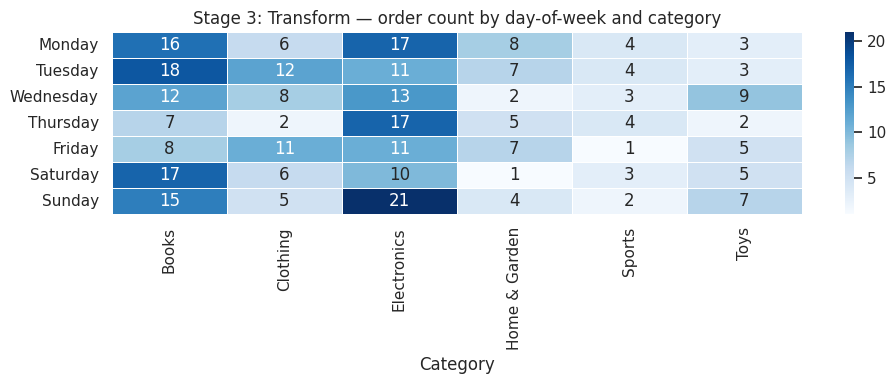

In [55]:
# Orders per day-of-week × category
dow_cat = df_completed.groupby(['order_dow_name', 'category'])['order_id'].count().unstack(fill_value=0)
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_cat = dow_cat.reindex([d for d in day_order if d in dow_cat.index])

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(dow_cat, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('Stage 3: Transform — order count by day-of-week and category')
ax.set_xlabel('Category'); ax.set_ylabel('')
plt.tight_layout()
plt.show()


---
## Stage 4 — Feature Engineering

> *Engineer features to create predictive variables.*

Feature engineering turns raw signals into model-ready inputs. We build a **customer-level feature table** — one row per customer — suitable for a churn or LTV model.

Features we'll create:

| Feature | Description |
|---|---|
| `n_orders` | total number of completed orders |
| `total_revenue` | total spend |
| `avg_order_value` | mean spend per order |
| `std_order_value` | variability in spend |
| `max_order_value` | largest single order |
| `unique_categories` | product diversity |
| `avg_discount` | price sensitivity proxy |
| `recency_days` | days since last order |
| `tenure_days` | days since signup to last order |
| `is_weekend_shopper` | majority of orders on weekends |
| `age_group` | binned age |
| `city_encoded` | frequency-encoded city |


### 4.1 — Customer-level aggregation

In [56]:
latest_date = df_completed['order_date'].max()

customer_features = (
    df_completed
    .groupby('customer_id')
    .agg(
        n_orders          = ('order_id',   'count'),
        total_revenue     = ('revenue',    'sum'),
        avg_order_value   = ('revenue',    'mean'),
        std_order_value   = ('revenue',    'std'),
        max_order_value   = ('revenue',    'max'),
        unique_categories = ('category',   'nunique'),
        avg_discount      = ('discount',   'mean'),
        last_order_date   = ('order_date', 'max'),
        first_order_date  = ('order_date', 'min'),
    )
    .reset_index()
)

customer_features['recency_days'] = (latest_date - customer_features['last_order_date']).dt.days
customer_features['tenure_days']  = (customer_features['last_order_date'] -
                                      customer_features['first_order_date']).dt.days
customer_features['std_order_value'] = customer_features['std_order_value'].fillna(0)

customer_features.drop(columns=['last_order_date', 'first_order_date'], inplace=True)

print(f"Customer feature table: {customer_features.shape}")
customer_features.head(5)


Customer feature table: (112, 10)


,customer_id,n_orders,total_revenue,avg_order_value,std_order_value,max_order_value,unique_categories,avg_discount,recency_days,tenure_days
0,C0000,4,3509.21,877.30,453.83,1500.20,3,0.05,34,581
1,C0001,4,2288.48,572.12,299.01,850.86,3,0.09,29,599
2,C0002,2,836.18,418.09,20.49,432.58,1,0.05,126,511
3,C0004,1,1713.43,1713.43,0.00,1713.43,1,0.15,510,0
4,C0005,2,1367.57,683.78,800.05,1249.51,2,0.05,35,365


### 4.2 — Behavioural & categorical features

In [57]:
# Weekend shopper flag
weekend_orders = (
    df_completed
    .assign(is_weekend=df_completed['order_dow'] >= 5)
    .groupby('customer_id')['is_weekend']
    .mean()
    .rename('weekend_ratio')
)
customer_features = customer_features.merge(weekend_orders, on='customer_id', how='left')
customer_features['is_weekend_shopper'] = (customer_features['weekend_ratio'] >= 0.5).astype(int)

# Bring in static customer attributes
customer_features = customer_features.merge(
    customers[['customer_id', 'age', 'city', 'gender']],
    on='customer_id', how='left'
)

# Bin age → age_group
bins   = [0, 25, 35, 50, 100]
labels = ['18-25', '26-35', '36-50', '51+']
customer_features['age_group'] = pd.cut(customer_features['age'], bins=bins, labels=labels)

# Frequency-encode city
city_freq = customer_features['city'].value_counts(normalize=True).rename('city_encoded')
customer_features = customer_features.merge(city_freq, left_on='city', right_index=True, how='left')

print(f"Feature table after engineering: {customer_features.shape}")
customer_features[['customer_id','n_orders','total_revenue','recency_days',
                   'is_weekend_shopper','age_group','city_encoded']].head(5)


Feature table after engineering: (112, 17)


,customer_id,n_orders,total_revenue,recency_days,is_weekend_shopper,age_group,city_encoded
0,C0000,4,3509.21,34,0,18-25,0.16
1,C0001,4,2288.48,29,1,51+,0.10
2,C0002,2,836.18,126,1,36-50,0.10
3,C0004,1,1713.43,510,0,36-50,0.05
4,C0005,2,1367.57,35,1,51+,0.13


### 4.3 — Encode & scale for modelling

In [58]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

feat_df = customer_features.copy()

# Label-encode gender and age_group
le = LabelEncoder()
feat_df['gender_enc']    = le.fit_transform(feat_df['gender'].fillna('Unknown'))
feat_df['age_group_enc'] = le.fit_transform(feat_df['age_group'].astype(str))

numeric_cols = [
    'n_orders', 'total_revenue', 'avg_order_value', 'std_order_value',
    'max_order_value', 'unique_categories', 'avg_discount',
    'recency_days', 'tenure_days', 'city_encoded',
    'gender_enc', 'age_group_enc'
]

scaler = StandardScaler()
scaled = pd.DataFrame(scaler.fit_transform(feat_df[numeric_cols]),
                       columns=[c + '_z' for c in numeric_cols])

print("Scaled feature sample (z-scores):")
scaled.head(3)


Scaled feature sample (z-scores):


,n_orders_z,total_revenue_z,avg_order_value_z,std_order_value_z,max_order_value_z,unique_categories_z,avg_discount_z,recency_days_z,tenure_days_z,city_encoded_z,gender_enc_z,age_group_enc_z
0,0.70,1.12,0.51,0.18,0.62,0.76,-1.03,-1.08,1.27,1.51,0.31,-1.93
1,0.70,0.20,-0.27,-0.34,-0.44,0.76,-0.22,-1.11,1.35,-0.39,-1.03,1.03
2,-0.65,-0.90,-0.67,-1.28,-1.13,-1.39,-1.03,-0.55,0.94,-0.39,0.31,0.04


### 4.4 — Feature correlation heatmap

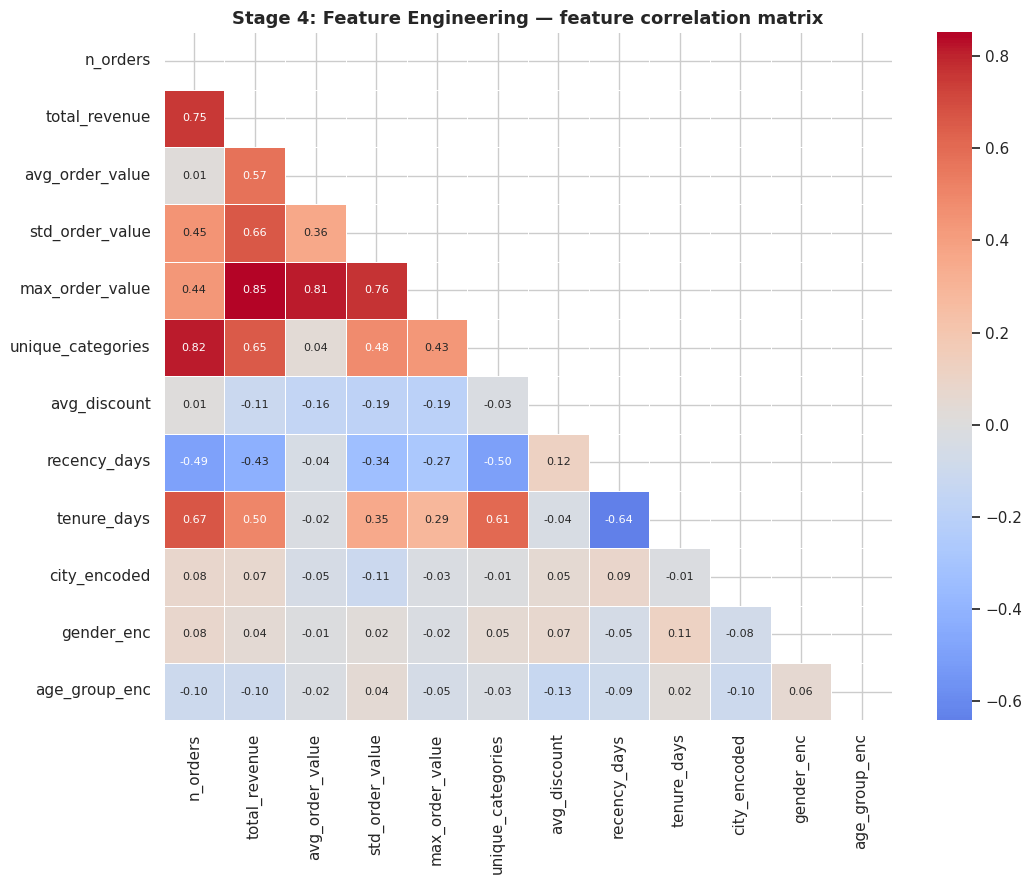

In [59]:
corr = feat_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size': 8})
ax.set_title('Stage 4: Feature Engineering — feature correlation matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.5 — Feature distributions

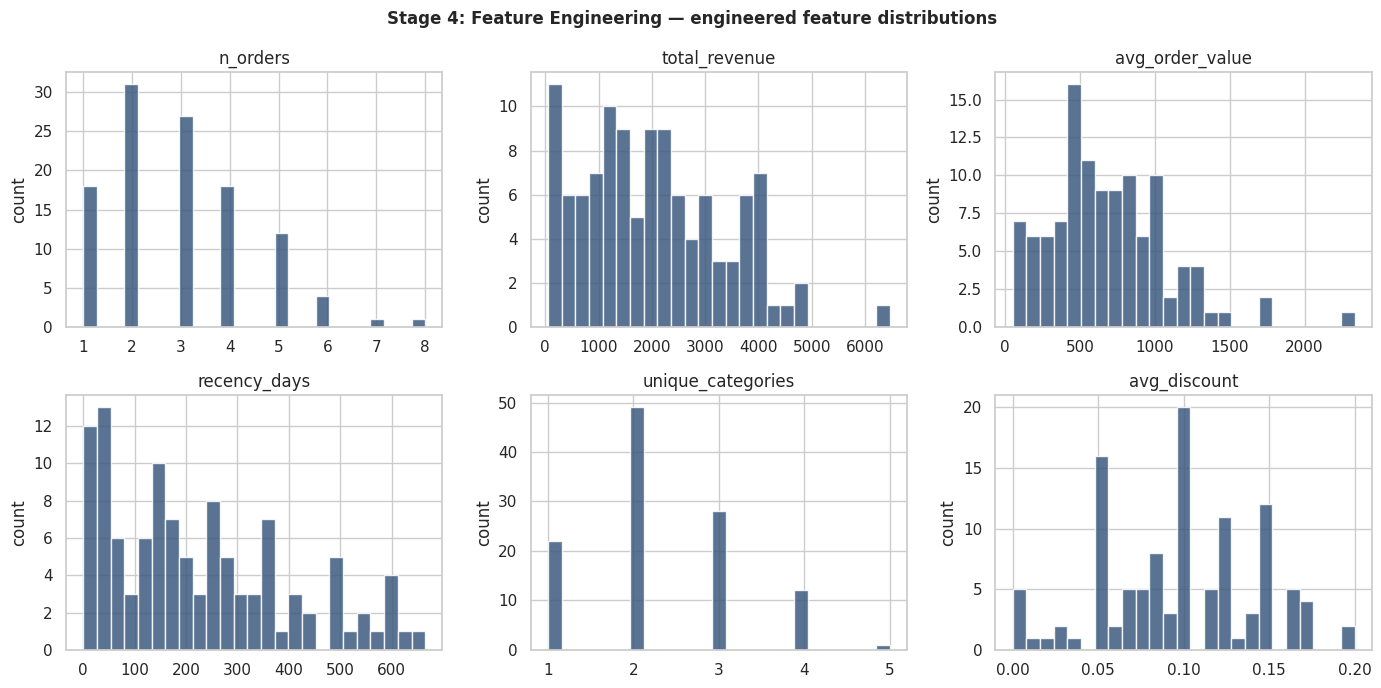

In [60]:
plot_cols = ['n_orders', 'total_revenue', 'avg_order_value', 'recency_days',
             'unique_categories', 'avg_discount']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, plot_cols):
    ax.hist(feat_df[col].dropna(), bins=25, color='#3d5a80', edgecolor='white', alpha=0.85)
    ax.set_title(col); ax.set_xlabel(''); ax.set_ylabel('count')

fig.suptitle('Stage 4: Feature Engineering — engineered feature distributions',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Pipeline Summary

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 815 95" width="815" height="95">
  <!-- Raw Sources -->
  <rect x="5" y="10" width="110" height="70" rx="8" fill="#455A64"/>
  <text x="60" y="37" text-anchor="middle" fill="white" font-family="Arial,sans-serif" font-size="12" font-weight="bold">Raw Sources</text>
  <text x="60" y="57" text-anchor="middle" fill="#CFD8DC" font-family="Arial,sans-serif" font-size="10">(3 tables)</text>
  <!-- Arrow 1 -->
  <line x1="115" y1="45" x2="125" y2="45" stroke="#607D8B" stroke-width="2"/>
  <polygon points="125,39 137,45 125,51" fill="#607D8B"/>
  <!-- Stage 1: Ingest -->
  <rect x="137" y="10" width="110" height="70" rx="8" fill="#0277BD"/>
  <text x="192" y="37" text-anchor="middle" fill="white" font-family="Arial,sans-serif" font-size="11" font-weight="bold">1 — Ingest</text>
  <text x="192" y="57" text-anchor="middle" fill="#BBDEFB" font-family="Arial,sans-serif" font-size="10">load · report</text>
  <!-- Arrow 2 -->
  <line x1="247" y1="45" x2="257" y2="45" stroke="#607D8B" stroke-width="2"/>
  <polygon points="257,39 269,45 257,51" fill="#607D8B"/>
  <!-- Stage 2: Clean -->
  <rect x="269" y="10" width="110" height="70" rx="8" fill="#2E7D32"/>
  <text x="324" y="37" text-anchor="middle" fill="white" font-family="Arial,sans-serif" font-size="11" font-weight="bold">2 — Clean</text>
  <text x="324" y="57" text-anchor="middle" fill="#C8E6C9" font-family="Arial,sans-serif" font-size="10">impute · dedup</text>
  <!-- Arrow 3 -->
  <line x1="379" y1="45" x2="389" y2="45" stroke="#607D8B" stroke-width="2"/>
  <polygon points="389,39 401,45 389,51" fill="#607D8B"/>
  <!-- Stage 3: Transform -->
  <rect x="401" y="10" width="120" height="70" rx="8" fill="#E65100"/>
  <text x="461" y="37" text-anchor="middle" fill="white" font-family="Arial,sans-serif" font-size="11" font-weight="bold">3 — Transform</text>
  <text x="461" y="57" text-anchor="middle" fill="#FFE0B2" font-family="Arial,sans-serif" font-size="10">join · derive · filter</text>
  <!-- Arrow 4 -->
  <line x1="521" y1="45" x2="531" y2="45" stroke="#607D8B" stroke-width="2"/>
  <polygon points="531,39 543,45 531,51" fill="#607D8B"/>
  <!-- Stage 4: Feature Engineering -->
  <rect x="543" y="10" width="155" height="70" rx="8" fill="#6A1B9A"/>
  <text x="620" y="37" text-anchor="middle" fill="white" font-family="Arial,sans-serif" font-size="11" font-weight="bold">4 — Feature Eng.</text>
  <text x="620" y="57" text-anchor="middle" fill="#E1BEE7" font-family="Arial,sans-serif" font-size="10">aggregate · encode · scale</text>
  <!-- Arrow 5 -->
  <line x1="698" y1="45" x2="708" y2="45" stroke="#607D8B" stroke-width="2"/>
  <polygon points="708,39 720,45 708,51" fill="#607D8B"/>
  <!-- Model -->
  <rect x="720" y="10" width="88" height="70" rx="8" fill="#B71C1C"/>
  <text x="764" y="48" text-anchor="middle" fill="white" font-family="Arial,sans-serif" font-size="13" font-weight="bold">Model</text>
</svg>

| Stage | Input rows | Output rows | Key operations |
|---|---|---|---|
| Ingest | — | 625 orders / 125 customers / 30 products | `pd.read_*`, ingest report |
| Clean | as above | 510 orders / 120 customers / 30 products | drop_duplicates, fillna, str.strip |
| Transform | 510 orders | ~355 completed + join (510 × 9 cols → 510 × 16) | merge, dt accessors, groupby |
| Feature Engineering | 510 × 16 | 1 row per customer × 15 features | agg, cut, LabelEncoder, StandardScaler |

### Key takeaways
- **Order matters** — clean before joining; join before aggregating; aggregate before encoding.
- **Trace every step** — ingest reports catch schema drift early.
- **Imputation strategy depends on distribution** — median for skewed numerics, mode for counts, group-median for prices.
- **Feature engineering is domain-driven** — `recency_days`, `is_weekend_shopper`, and `city_encoded` all encode business intuition.